In [1]:
# Importing the Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Loading the Data
df = pd.read_csv('ai_financial_market.csv')

In [3]:
# Analyse the Top 5 rows of the data
df.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09


In [5]:
# Now let's check for more information on the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 10959 non-null  object 
 1   Company              10959 non-null  object 
 2   R&D_Spending_USD_Mn  10959 non-null  float64
 3   AI_Revenue_USD_Mn    10959 non-null  float64
 4   AI_Revenue_Growth_%  10959 non-null  float64
 5   Event                233 non-null    object 
 6   Stock_Impact_%       10959 non-null  float64
dtypes: float64(4), object(3)
memory usage: 599.4+ KB


In [7]:
# Convert the data type of the column Date from object to data
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 10959 non-null  datetime64[ns]
 1   Company              10959 non-null  object        
 2   R&D_Spending_USD_Mn  10959 non-null  float64       
 3   AI_Revenue_USD_Mn    10959 non-null  float64       
 4   AI_Revenue_Growth_%  10959 non-null  float64       
 5   Event                233 non-null    object        
 6   Stock_Impact_%       10959 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 599.4+ KB


In [10]:
# Now let's check how many unique companies are present in the data
df['Company'].unique()

array(['OpenAI', 'Google', 'Meta'], dtype=object)

In [11]:
# Now let's add a Year column in the data
df['Year'] = df['Date'].dt.year

In [13]:
df.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23,2015
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93,2015
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09,2015


#### Exploratary Data Analysis

#### 1. How much amount the companies spent on R&D?

In [22]:
print('Companies spending for R&D in $Billion')

RD = df.groupby('Company')['R&D_Spending_USD_Mn'].sum() / 1000

RD

Companies spending for R&D in $Billion


Company
Google    423.34114
Meta      264.53307
OpenAI     26.48277
Name: R&D_Spending_USD_Mn, dtype: float64

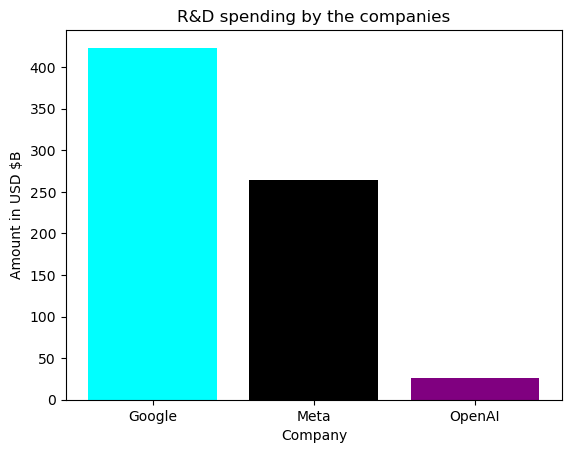

In [29]:
# We will plot a Bar Plot to show the amount spent on R&D by the companies

plt.bar(x = RD.index, height = RD.values, color = ['cyan', 'black', 'purple'], )
plt.title('R&D spending by the companies')
plt.xlabel('Company')
plt.ylabel('Amount in USD $B')
plt.show()

#### 2. How much revenue did the companies earned?

In [35]:
rev_earned = df.groupby('Company')['AI_Revenue_USD_Mn'].sum() / 1000

rev_earned

Company
Google    284.49838
Meta      189.62182
OpenAI      9.46289
Name: AI_Revenue_USD_Mn, dtype: float64

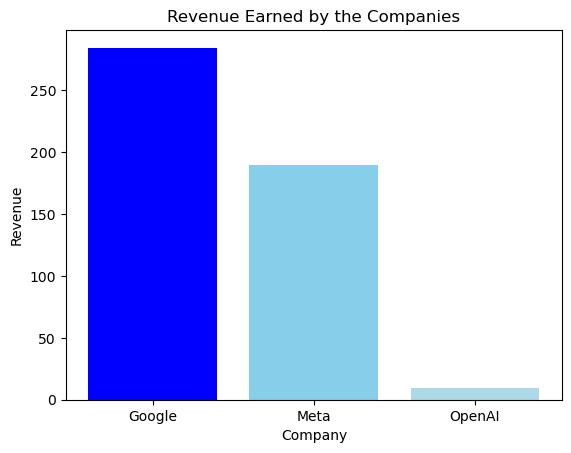

In [39]:
# Now let's plot a bar to show the revenue earned by the companies
plt.bar(x = rev_earned.index, height= rev_earned.values, color = ['blue', 'skyblue', 'lightblue'])
plt.title('Revenue Earned by the Companies')
plt.xlabel('Company')
plt.ylabel('Revenue')
plt.show()

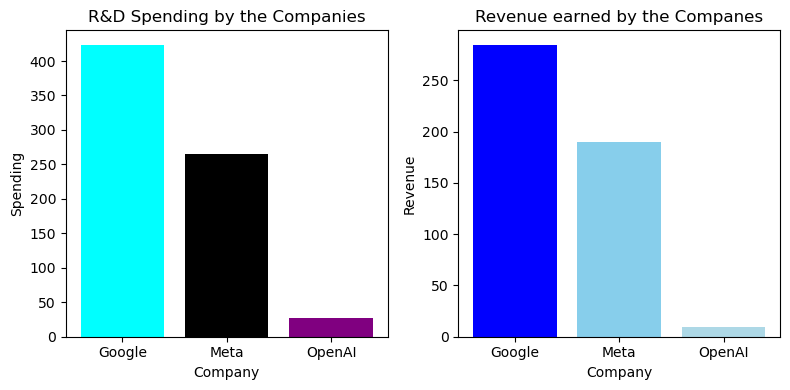

In [44]:
# Now let's plot a subplot to show the Expenditure and Revenue of the company
plt.figure(figsize= (8,4))
plt.subplot(1, 2, 1)
plt.bar(x = RD.index, height= RD.values, color = ['cyan', 'black', 'purple'])
plt.title('R&D Spending by the Companies')
plt.xlabel('Company')
plt.ylabel('Spending')


plt.subplot(1, 2, 2)
plt.bar(x = rev_earned.index, height= rev_earned.values, color = ['blue', 'skyblue', 'lightblue'])
plt.title('Revenue earned by the Companes')
plt.xlabel('Company')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

#### 3. What was the Datewise impact on the Stock

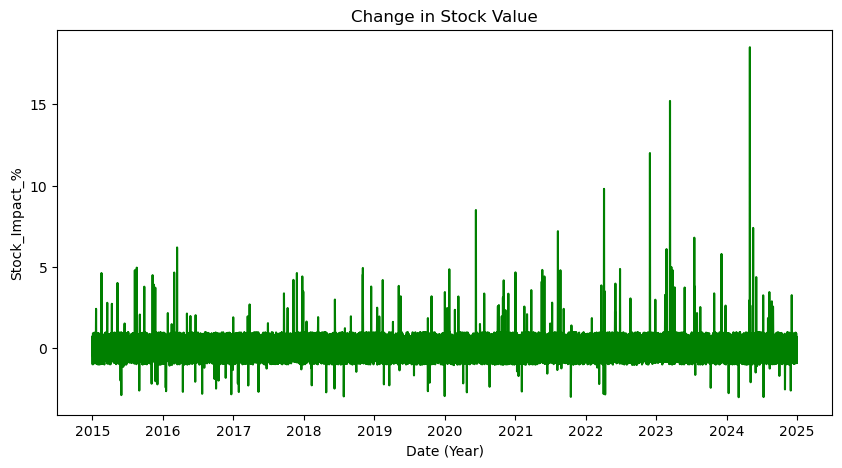

In [47]:
plt.figure(figsize= (10,5))

plt.plot(df['Date'], df['Stock_Impact_%'], color = 'green')
plt.title('Change in Stock Value')
plt.xlabel('Date (Year)')
plt.ylabel('Stock_Impact_%')
plt.show()

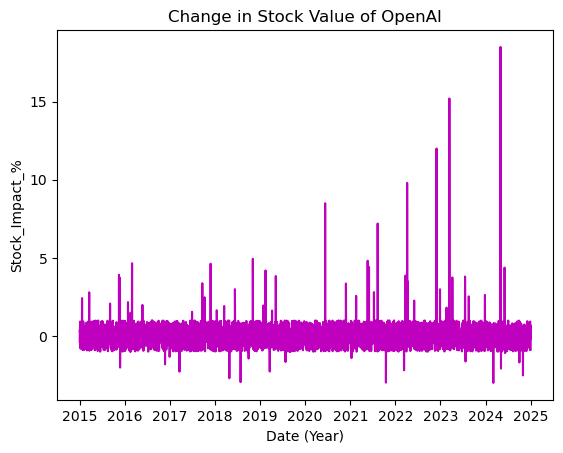

In [58]:
# Now let's check for each company separately
data_openAI = df[df['Company'] == 'OpenAI']

plt.plot(data_openAI['Date'], data_openAI['Stock_Impact_%'], color = 'm')
plt.title('Change in Stock Value of OpenAI')
plt.xlabel('Date (Year)')
plt.ylabel('Stock_Impact_%')
plt.show()

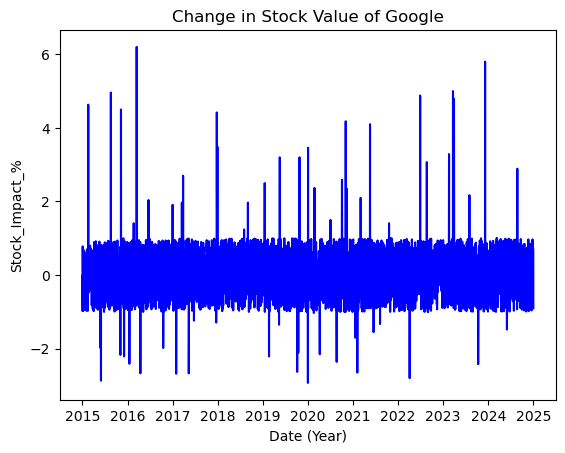

In [60]:
data_google = df[df['Company'] == 'Google']
plt.plot(data_google['Date'], data_google['Stock_Impact_%'], color = 'blue')
plt.title('Change in Stock Value of Google')
plt.xlabel('Date (Year)')
plt.ylabel('Stock_Impact_%')
plt.show()

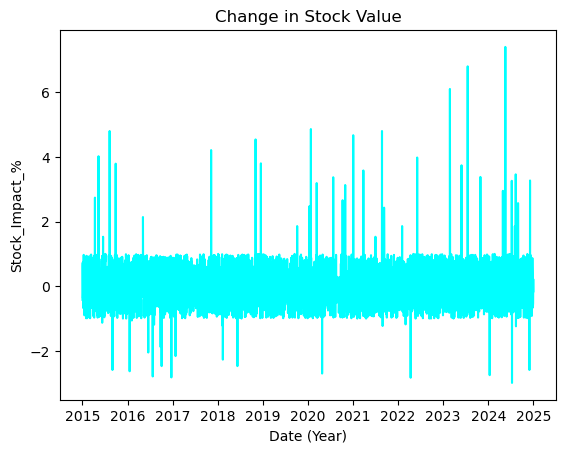

In [61]:
data_meta = df[df['Company'] == 'Meta']

plt.plot(data_meta['Date'], data_meta['Stock_Impact_%'], color = 'cyan')
plt.title('Change in Stock Value')
plt.xlabel('Date (Year)')
plt.ylabel('Stock_Impact_%')
plt.show()

#### Events when Maximum Stock Impact was observed

In [62]:
# OpenAI's Events when maximum stock impact was observed

data_openAI.sort_values(by = 'Stock_Impact_%', ascending= False)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
3408,2024-05-01,OpenAI,10.91,5.34,434.27,GPT-5 release (predicted),18.50,2024
2994,2023-03-14,OpenAI,7.78,4.05,304.57,GPT-4 release,15.20,2023
2890,2022-11-30,OpenAI,10.60,3.18,217.72,ChatGPT (GPT-3.5) launch,12.00,2022
2652,2022-04-06,OpenAI,9.24,3.48,247.93,DALL·E 2 release,9.80,2022
1988,2020-06-11,OpenAI,5.90,2.62,161.56,GPT-3 release,8.50,2020
...,...,...,...,...,...,...,...,...
3590,2024-10-30,OpenAI,11.05,5.27,427.50,AI-powered search update,-2.52,2024
1212,2018-04-27,OpenAI,5.38,1.76,76.47,AI ethics policy update,-2.70,2018
1303,2018-07-27,OpenAI,7.44,0.97,-2.63,AI-powered search update,-2.95,2018
2480,2021-10-16,OpenAI,8.39,2.78,178.28,AI Ads Optimization upgrade,-2.98,2021


In [63]:
data_google.sort_values(by = 'Stock_Impact_%', ascending= False)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
4092,2016-03-15,Google,84.56,36.22,20.73,AlphaGo beats Lee Sedol,6.20,2016
6914,2023-12-06,Google,146.59,129.17,330.55,Gemini AI release,5.80,2023
6654,2023-03-21,Google,149.34,129.76,332.53,Bard chatbot launch,5.00,2023
3883,2015-08-19,Google,79.27,30.89,2.98,AI partnership deal,4.96,2015
6388,2022-06-28,Google,137.71,107.96,259.85,AI ethics policy update,4.88,2022
...,...,...,...,...,...,...,...,...
4122,2016-04-14,Google,87.19,36.08,20.28,AI partnership deal,-2.67,2016
4412,2017-01-29,Google,92.21,43.25,44.17,AI Ads Optimization upgrade,-2.68,2017
6303,2022-04-04,Google,138.00,106.81,256.04,AI Video Recommendation upgrade,-2.80,2022
3803,2015-05-31,Google,81.14,29.30,-2.32,Cloud AI launch,-2.87,2015


In [64]:
data_meta.sort_values(by = 'Stock_Impact_%', ascending= False)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
10731,2024-05-18,Meta,103.64,103.05,415.23,LLaMA 3 release (predicted),7.40,2024
10426,2023-07-18,Meta,92.44,85.67,328.37,LLaMA 2 release,6.80,2023
10282,2023-02-24,Meta,93.71,86.98,334.89,LLaMA 1 release,6.10,2023
9156,2020-01-25,Meta,72.73,49.10,145.49,Cloud AI launch,4.86,2020
9732,2021-08-23,Meta,78.19,59.36,196.79,Cloud AI launch,4.80,2021
...,...,...,...,...,...,...,...,...
10604,2024-01-12,Meta,99.37,104.28,421.42,AI Video Recommendation upgrade,-2.75,2024
7875,2016-07-23,Meta,53.76,23.97,19.83,AI-powered search update,-2.79,2016
8026,2016-12-21,Meta,53.18,23.42,17.11,AI-powered search update,-2.82,2016
9964,2022-04-12,Meta,84.90,71.99,259.95,AI ethics policy update,-2.83,2022


#### AI Revenue Growth of the Companies

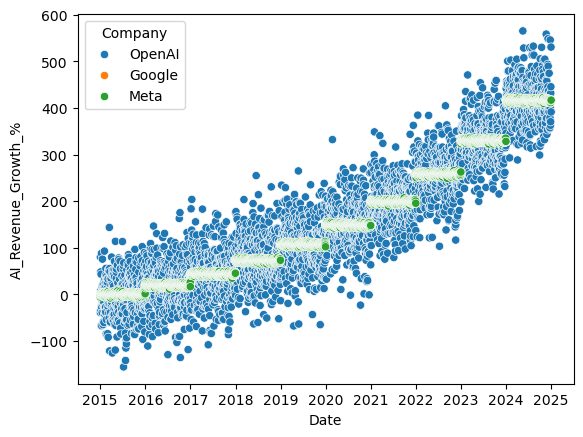

In [66]:
sns.scatterplot(x = 'Date', y = 'AI_Revenue_Growth_%', data= df, hue = 'Company')
plt.show()

#### Revenue Growth of Companies Year on Year

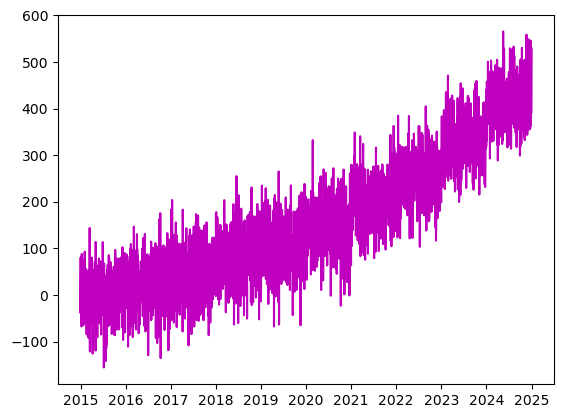

In [70]:
# Open AI
plt.plot(data_openAI['Date'],  data_openAI['AI_Revenue_Growth_%'], color = 'm')
plt.show()

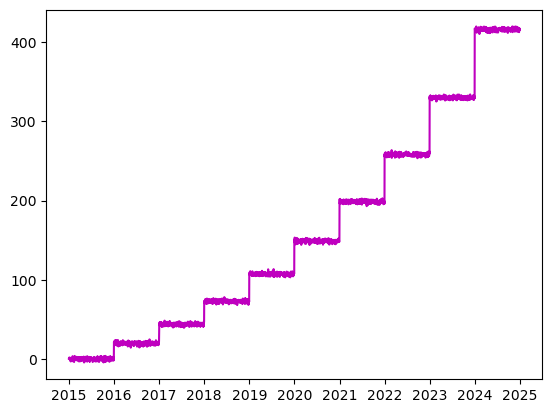

In [71]:
# Open AI
plt.plot(data_google['Date'],  data_google['AI_Revenue_Growth_%'], color = 'm')
plt.show()

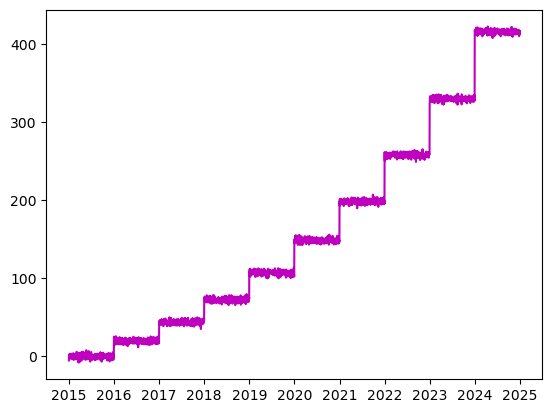

In [72]:
# Open AI
plt.plot(data_meta['Date'],  data_meta['AI_Revenue_Growth_%'], color = 'm')
plt.show()

#### Correlation between columns

In [73]:
df.corr(numeric_only= True)

,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Stock_Impact_%,Year
R&D_Spending_USD_Mn,1.000000,0.935030,0.291245,-0.004628,0.297701
AI_Revenue_USD_Mn,0.935030,1.000000,0.530128,-0.000017,0.526478
AI_Revenue_Growth_%,0.291245,0.530128,1.000000,0.020937,0.952199
Stock_Impact_%,-0.004628,-0.000017,0.020937,1.000000,0.016525
Year,0.297701,0.526478,0.952199,0.016525,1.000000


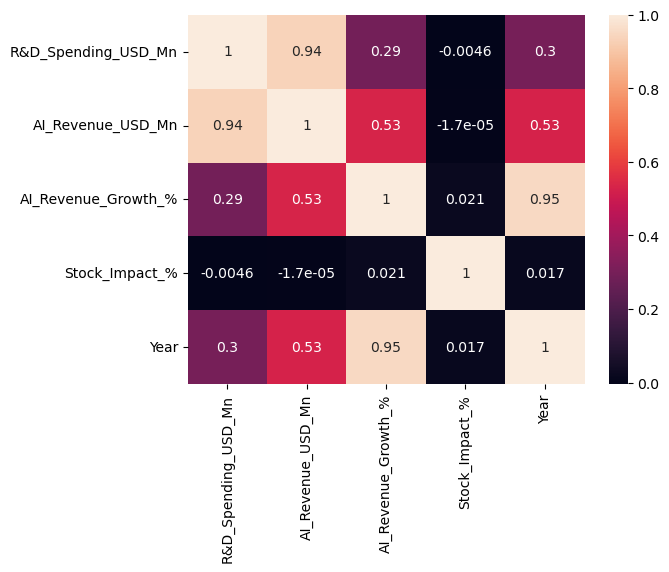

In [75]:
sns.heatmap(df.corr(numeric_only= True), annot= True)
plt.show()

#### Expenditure VS Revenue Year on Year

In [79]:
spend = df.groupby('Year')['R&D_Spending_USD_Mn'].sum()

spend

Year
2015    49304.23
2016    53349.94
2017    57475.12
2018    62002.16
2019    67071.51
2020    72602.53
2021    78207.32
2022    84390.17
2023    91193.92
2024    98760.08
Name: R&D_Spending_USD_Mn, dtype: float64

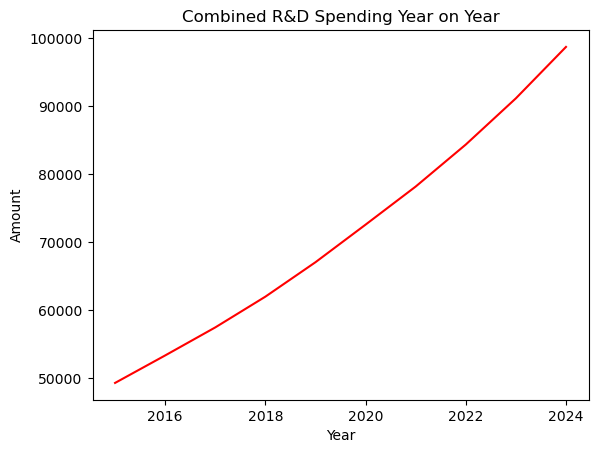

In [81]:
plt.plot(spend.index, spend.values, color = 'r')
plt.title('Combined R&D Spending Year on Year')
plt.xlabel('Year')
plt.ylabel('Amount')
plt.show()

In [83]:
revenue = df.groupby('Year')['AI_Revenue_USD_Mn'].sum()

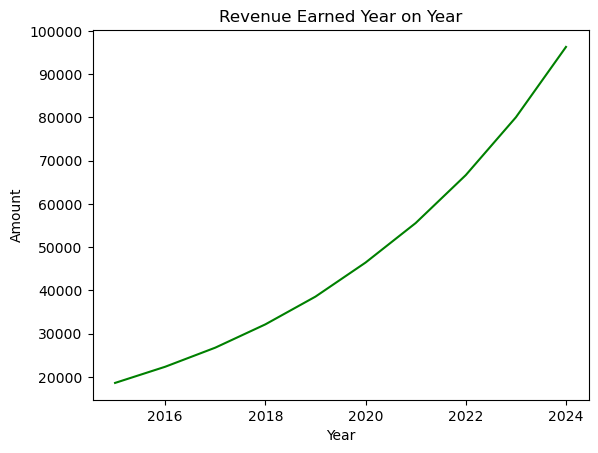

In [85]:
plt.plot(revenue.index, revenue.values, color = 'g')
plt.title('Revenue Earned Year on Year')
plt.xlabel('Year')
plt.ylabel('Amount')
plt.show()

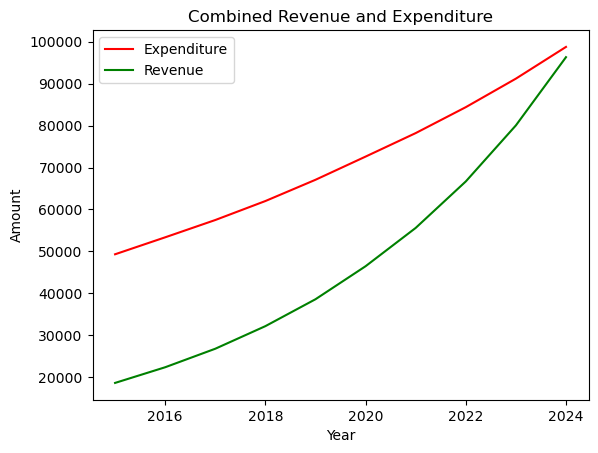

In [91]:
plt.plot(spend.index, spend.values, color = 'r')
plt.plot(revenue.index, revenue.values, color = 'g')
plt.title('Combined Revenue and Expenditure', fontsize = 12)
plt.xlabel('Year')
plt.ylabel('Amount')
plt.legend(['Expenditure', 'Revenue'])
plt.show()

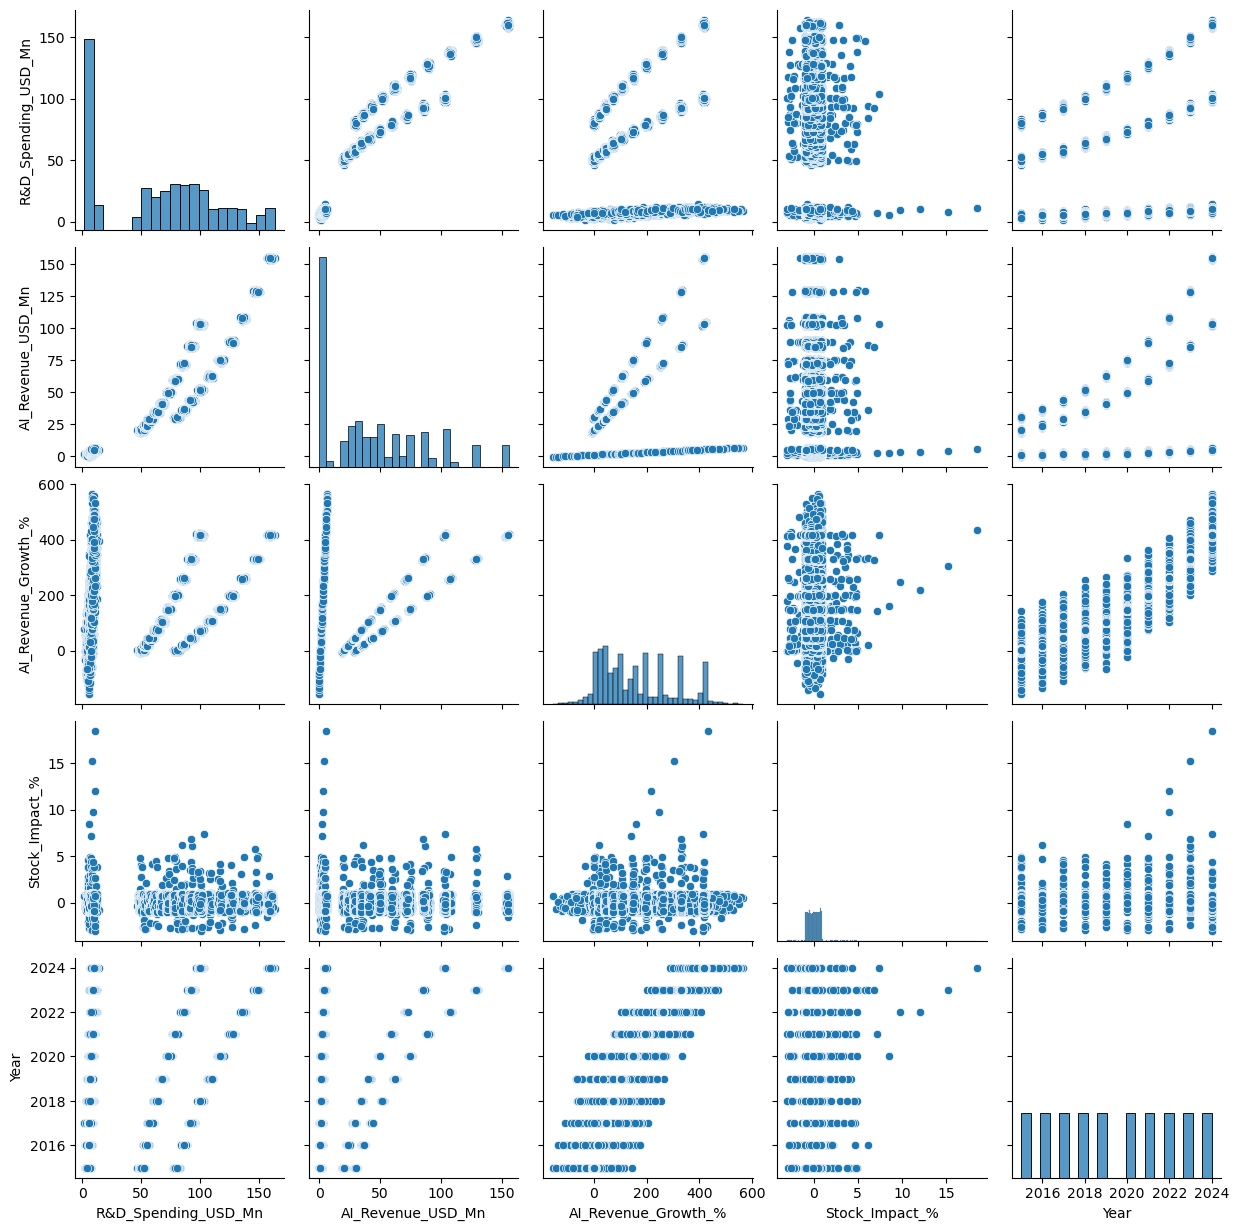

In [92]:
# Pairplot to show the relationship between the columns
sns.pairplot(df)
plt.show()

#### Event Impact Analysis

In [93]:
df['Event'].value_counts()

Event
AI speech recognition release      37
AI-powered search update           32
AI Ads Optimization upgrade        32
AI partnership deal                32
AI Video Recommendation upgrade    29
Cloud AI launch                    27
AI ethics policy update            27
TensorFlow open-source release      1
LLaMA 2 release                     1
LLaMA 1 release                     1
Gemini AI release                   1
Bard chatbot launch                 1
MUM Search Model launch             1
BERT for Search launch              1
AlphaGo beats Lee Sedol             1
ChatGPT (GPT-3.5) launch            1
GPT-5 release (predicted)           1
GPT-4 release                       1
DALL·E 2 release                    1
Codex release                       1
GPT-3 release                       1
GPT-2 release                       1
GPT-1 release                       1
LLaMA 3 release (predicted)         1
Name: count, dtype: int64

In [94]:
df[df['Event'] == 'TensorFlow open-source release']

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
3965,2015-11-09,Google,79.62,29.84,-0.53,TensorFlow open-source release,4.5,2015


In [97]:
tf = df.loc[3955: 3975]

tf

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
3955,2015-10-30,Google,80.33,29.87,-0.43,NaN,0.43,2015
3956,2015-10-31,Google,79.53,30.30,0.99,NaN,-0.84,2015
3957,2015-11-01,Google,80.37,29.86,-0.48,NaN,0.57,2015
3958,2015-11-02,Google,77.89,29.97,-0.10,NaN,0.76,2015
3959,2015-11-03,Google,81.00,29.43,-1.89,NaN,-0.45,2015
3960,2015-11-04,Google,80.70,29.71,-0.96,AI speech recognition release,-2.17,2015
3961,2015-11-05,Google,78.31,30.25,0.85,NaN,0.31,2015
3962,2015-11-06,Google,79.08,29.84,-0.54,NaN,-0.72,2015
3963,2015-11-07,Google,79.65,30.34,1.14,NaN,0.58,2015
3964,2015-11-08,Google,79.63,29.74,-0.86,NaN,-0.61,2015


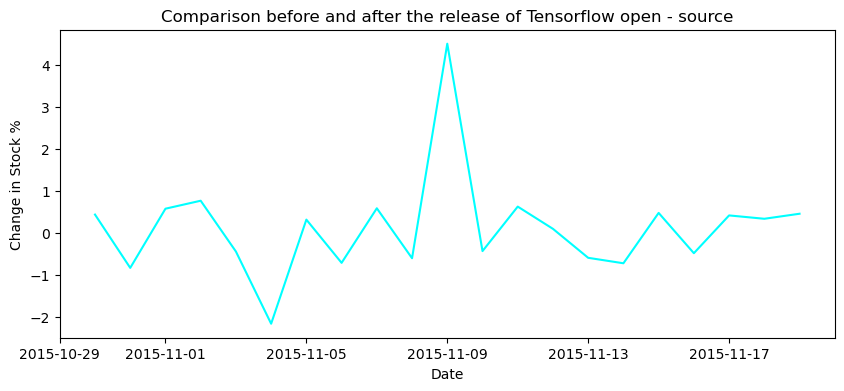

In [102]:
plt.figure(figsize= (10,4))
plt.plot(tf['Date'], tf['Stock_Impact_%'], color = 'cyan')
plt.title('Comparison before and after the release of Tensorflow open - source')
plt.xlabel('Date')
plt.ylabel('Change in Stock %')
plt.show()

#### Daily Average Impact on the Stocks of the Companies

In [105]:
df.groupby('Company')['Stock_Impact_%'].mean() * 100

Company
Google    2.620860
Meta      0.976184
OpenAI    4.070901
Name: Stock_Impact_%, dtype: float64

#### Daily Average Expenditure on R&D by the Companies

In [106]:
df.groupby('Company')['R&D_Spending_USD_Mn'].mean()

Company
Google    115.888623
Meta       72.415294
OpenAI      7.249595
Name: R&D_Spending_USD_Mn, dtype: float64

#### Maximum Impact % on a Companies Stock

In [107]:
df.groupby('Company')['Stock_Impact_%'].max()

Company
Google     6.2
Meta       7.4
OpenAI    18.5
Name: Stock_Impact_%, dtype: float64

#### Change in Index with reference to Year & Company

In [109]:
stocks = df.groupby(['Year', 'Company'])['Stock_Impact_%'].max()

In [110]:
stocks

Year  Company
2015  Google      4.96
      Meta        4.80
      OpenAI      3.92
2016  Google      6.20
      Meta        2.14
      OpenAI      4.66
2017  Google      4.42
      Meta        4.21
      OpenAI      4.63
2018  Google      1.97
      Meta        4.54
      OpenAI      4.94
2019  Google      3.20
      Meta        1.86
      OpenAI      4.20
2020  Google      4.18
      Meta        4.86
      OpenAI      8.50
2021  Google      4.10
      Meta        4.80
      OpenAI      7.20
2022  Google      4.88
      Meta        3.98
      OpenAI     12.00
2023  Google      5.80
      Meta        6.80
      OpenAI     15.20
2024  Google      2.89
      Meta        7.40
      OpenAI     18.50
Name: Stock_Impact_%, dtype: float64

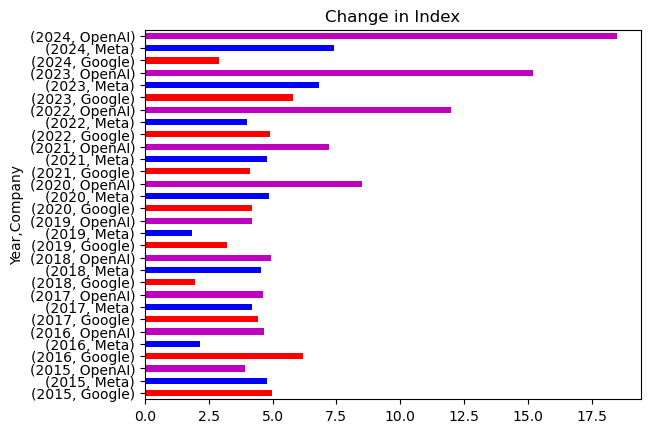

In [112]:
stocks.plot(kind= 'barh', color = ['r', 'b' ,'m'])
plt.title('Change in Index')
plt.show()